Проект для попытки реализовать расчёт метрик

На своих данных (двумерных для простоты)

In [2]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [1]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [3]:
data = pd.read_csv('file_for_input/all_hour/SBER_tradestats_test_hour.csv')

# ['vol','val','trades','trades_b','trades_s', 'val_b','val_s','vol_b','vol_s','pr_open_hour','pr_high_hour','pr_low_hour','pr_close_hour'] <- полный список параметров
X = data[['pr_open_hour']] # Не добавлются сюда другие лейблы
Y= data ['pr_close_hour']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [4]:
print("Размер обучающей выборки (X_train):", X_train.shape)
print("Размер тестовой выборки (X_test):", X_test.shape)
print("Размер меток обучающей выборки (y_train):", y_train.shape)
print("Размер меток тестовой выборки (y_test):", y_test.shape)

Размер обучающей выборки (X_train): (6820, 1)
Размер тестовой выборки (X_test): (1705, 1)
Размер меток обучающей выборки (y_train): (6820,)
Размер меток тестовой выборки (y_test): (1705,)


In [5]:
# Убедитесь, что device определен (проверить код в этой ячейке)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Создание правильного датасета для KAN
dataset = {
    'train_input': X_train_tensor,
    'train_label': y_train_tensor,
    'test_input': X_test_tensor,
    'test_label': y_test_tensor
}

In [7]:
dataset['train_input'].shape, dataset['train_label'].shape 

(torch.Size([5115, 1]), torch.Size([5115, 1]))

In [10]:
# Создание модели KAN с измененными параметрами
model = KAN(width=[1, 10, 1], grid=5, k=3, seed=0)

checkpoint directory created: ./model
saving model version 0.0


In [11]:
# Обучение модели
#results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
results = model.fit(dataset, opt="LBFGS", steps=50)
# Вывод результатов
train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
print(f'Train loss: {train_loss}, Test loss: {test_loss}')


| train_loss: 1.47e+00 | test_loss: 1.81e+00 | reg: 1.65e+01 | : 100%|█| 50/50 [00:16<00:00,  3.05it

saving model version 0.1
Train loss: 1.4733390808105469, Test loss: 1.8080333471298218


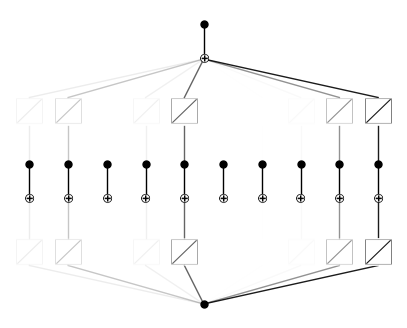

In [13]:
# Визуализация результатов, если это возможно
model.plot()

In [16]:
# Предположим, что у вас есть новая цена открытия часовой свечи, для которой нужно предсказать цену закрытия
new_open = int(335)  # Пример новой цены открытия

# Преобразуем новой цены открытия в тензор PyTorch и добавляем дополнительное измерение
new_open_tensor = torch.tensor([[new_open]], dtype=torch.float32)

# Используем метод forward модели KAN для получения предсказания
predicted_shoe_size = model(new_open_tensor)

# Вывод предсказанного размера обуви
print("Предсказанный цена закрытия часа при цене открытия часа =", new_open, "руб  Будет равна:", predicted_shoe_size.item())  # Используйте .item() для получения скалярного значения из тензора

Предсказанный цена закрытия часа при цене открытия часа = 335 руб  Будет равна: 334.9461669921875


C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\kan\MultKAN.py:798: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\kan\MultKAN.py:808: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  input_range = torch.std(preacts, dim=0) + 0.1
C:\TRADE_LapTop\KanNootebook\venv\Lib\site-packages\kan\MultKAN.py:809: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input n

In [21]:

# Для KAN
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# Оценка для KAN
mse_kan = mean_squared_error(y_test, kan_predictions)
mae_kan = mean_absolute_error(y_test, kan_predictions)
r2_kan = r2_score(y_test, kan_predictions)


print("KAN - MSE:", mse_kan, "MAE:", mae_kan, "R^2:", r2_kan)

KAN - MSE: 3.2689841420614094 MAE: 0.8457998958822569 R^2: 0.9992991449261964


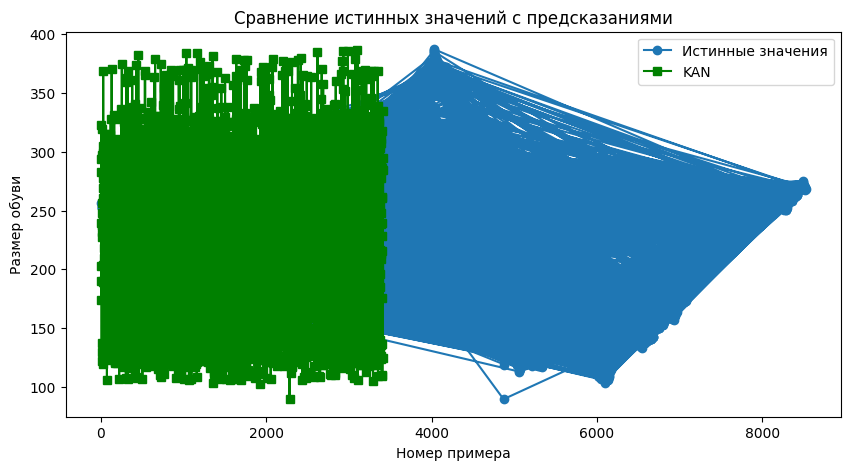

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Истинные значения', marker='o')
plt.plot(kan_predictions, 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказаниями')
plt.xlabel('Номер примера')
plt.ylabel('Размер обуви')
plt.legend()
plt.show()


В этом примере речь идёт о RMSE https://kindxiaoming.github.io/pykan/Example/Example_3_deep_formula.html

в кане по идеи нужно использовать эту функцию: evaluate(dataset)

In [13]:
# Функция evaluate в нейронных сетях возвращает значение функции потерь и метрики точности на тестовых данных. Эти значения позволяют оценить, насколько хорошо модель обобщает на новые данные. 1
# Для оценки модели нужно вызвать метод model.evaluate(x_test, y_test). 15

model.evaluate(dataset)

{'test_loss': 0.0014075100189074874, 'n_edge': 3, 'n_grid': 20}